In [1]:
import os, urllib.request
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage import data

In [2]:
os.makedirs('figures', exist_ok=True)
rng = np.random.default_rng(0)

In [3]:
def show(images, titles, size=4, save=None, cmap='gray'):
    plt.figure(figsize=(size * len(images), size))
    for i, (im, t) in enumerate(zip(images, titles)):
        plt.subplot(1, len(images), i + 1)
        if im.ndim == 2:
            plt.imshow(im, cmap=cmap, vmin=0, vmax=255)
        else:
            plt.imshow(im)
        plt.title(t); plt.axis('off')
    plt.tight_layout()
    if save:
        plt.savefig('figures/' + save, dpi=200, bbox_inches='tight')
    plt.show()

In [4]:
def edge_view(a):
    a = np.abs(a).astype(float)
    return 255 - np.clip(a / np.percentile(a, 99.5) * 255, 0, 255).astype(np.uint8)

In [5]:
url = 'https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data/building.jpg'
urllib.request.urlretrieve(url, 'building.jpg')
building = cv2.cvtColor(cv2.imread('building.jpg'), cv2.COLOR_BGR2RGB)
bgray = cv2.cvtColor(building, cv2.COLOR_RGB2GRAY)

In [6]:
cam   = data.camera()            # cameraman
crop  = cam[40:360, 120:440]     # the 320 x 320 crop used on the slides
cat   = data.chelsea()           # the cat
coins = data.coins()
print(building.shape, cam.shape, cat.shape, coins.shape)

(600, 868, 3) (512, 512) (300, 451, 3) (303, 384)


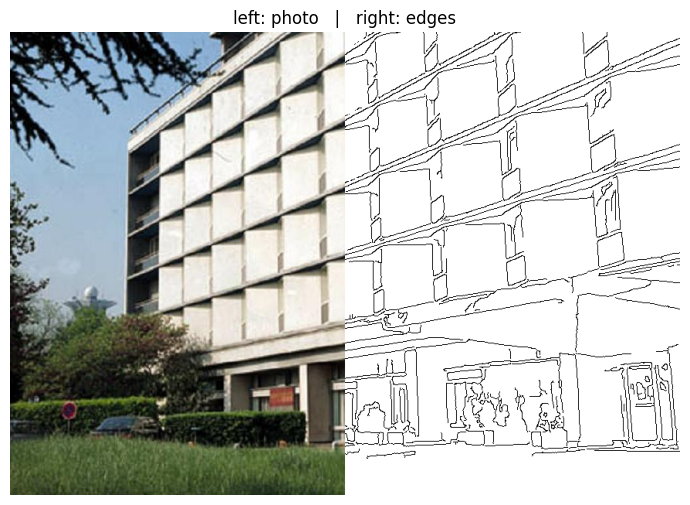

In [7]:
edges_b = cv2.Canny(cv2.GaussianBlur(bgray, (5, 5), 1.2), 50, 140)
half = bgray.shape[1] // 2
split = building.copy()
split[:, half:] = cv2.cvtColor(255 - edges_b, cv2.COLOR_GRAY2RGB)[:, half:]
show([split], ['left: photo   |   right: edges'], size=7, save='s01_title_split.png')

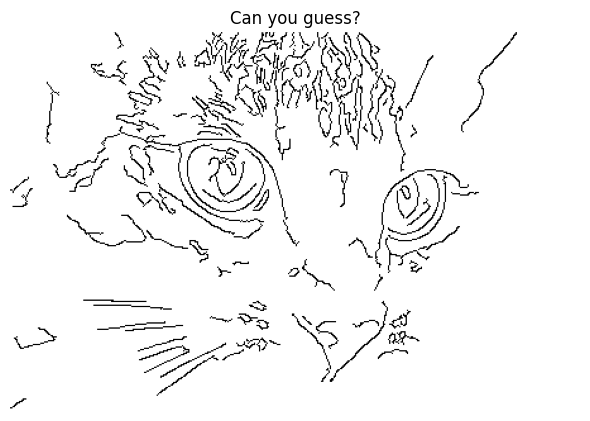

In [8]:
cat_gray = cv2.cvtColor(cat, cv2.COLOR_RGB2GRAY)
cat_edges = cv2.Canny(cv2.GaussianBlur(cat_gray, (5, 5), 1.4), 40, 110)
show([255 - cat_edges], ['Can you guess?'], size=6, save='s02_hook_edges.png')

The answer, and how many pixels are edges:

edge pixels: 5.0% of the image


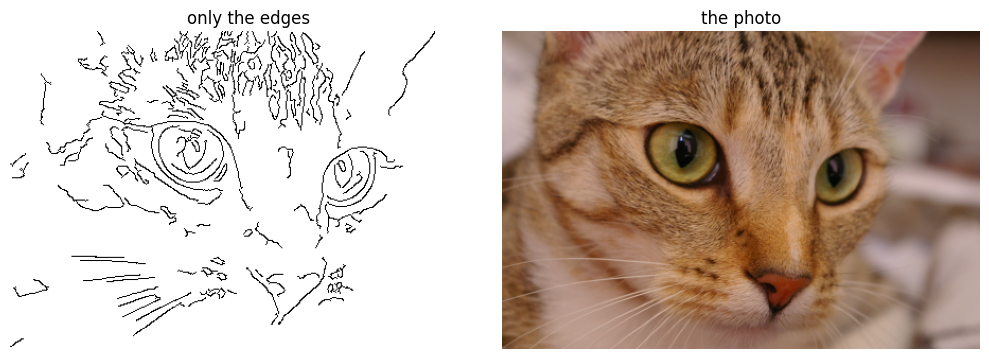

In [9]:
print(f'edge pixels: {(cat_edges > 0).mean() * 100:.1f}% of the image')
show([255 - cat_edges, cat], ['only the edges', 'the photo'], size=5, save='s03_hook_reveal.png')

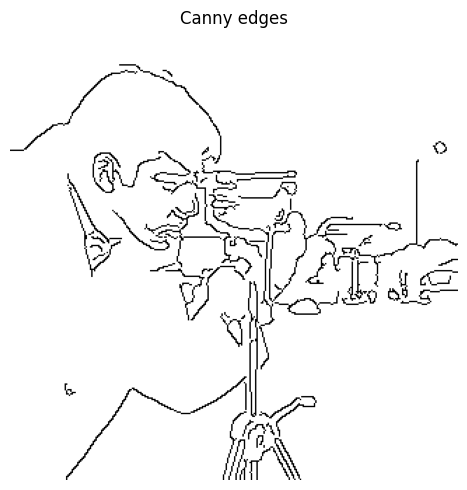

In [10]:
canny_cam = cv2.Canny(cv2.GaussianBlur(crop, (5, 5), 1.4), 50, 140)
show([255 - canny_cam], ['Canny edges'], size=5, save='s04_divider.png')

In [11]:
sq = (slice(40, 560), slice(200, 720))          # 520 x 520 crop
photo = building[sq]
edges = edges_b[sq]
print('pixels in the photo :', photo.shape[0] * photo.shape[1])
print(f'edge pixels         : {(edges > 0).mean() * 100:.1f}%')

pixels in the photo : 270400
edge pixels         : 7.8%


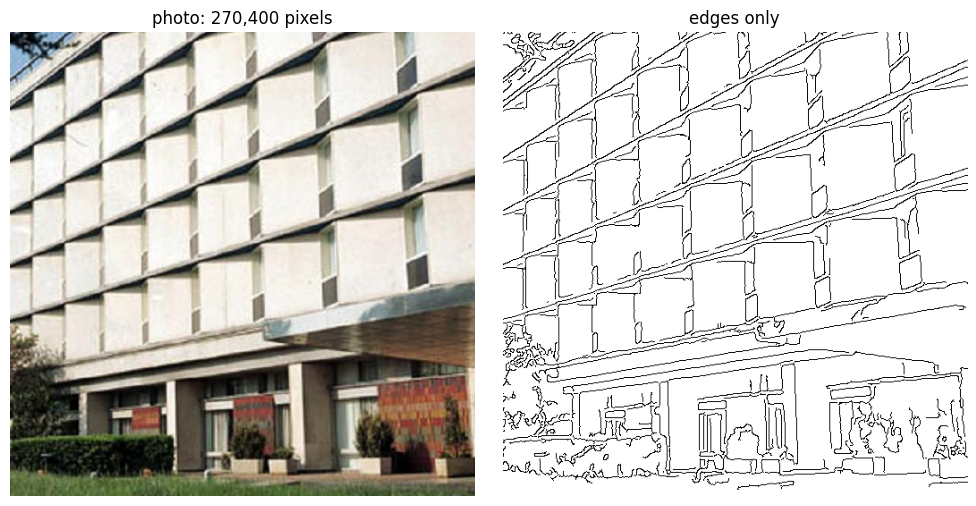

In [12]:
show([photo, 255 - edges], ['photo: 270,400 pixels', 'edges only'], size=5, save='s05_why_edges.png')

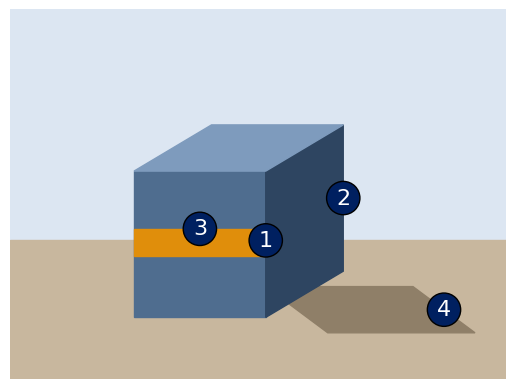

1 surface normal   2 depth   3 reflectance (paint)   4 illumination (shadow)


In [13]:
from matplotlib.patches import Polygon, Rectangle
fig, ax = plt.subplots(figsize=(6.4, 4.8))
ax.set_xlim(0, 640); ax.set_ylim(480, 0); ax.axis('off')
ax.add_patch(Rectangle((0, 0), 640, 300, color='#DCE6F2'))                 # wall
ax.add_patch(Rectangle((0, 300), 640, 180, color='#C8B79E'))               # table
ax.add_patch(Polygon([[330, 360], [520, 360], [600, 420], [410, 420]], color='#8F7F68'))   # shadow
ax.add_patch(Polygon([[160, 210], [330, 210], [330, 400], [160, 400]], color='#4F6D8F'))   # front face
ax.add_patch(Polygon([[330, 210], [430, 150], [430, 340], [330, 400]], color='#2E4561'))   # side face
ax.add_patch(Polygon([[160, 210], [260, 150], [430, 150], [330, 210]], color='#7E9BBD'))   # top face
ax.add_patch(Polygon([[160, 285], [330, 285], [330, 320], [160, 320]], color='#E08E0B'))   # painted stripe
for (x, y, t) in [(330, 300, '1'), (430, 245, '2'), (245, 285, '3'), (560, 390, '4')]:
    ax.text(x, y, t, fontsize=16, color='white', ha='center', va='center',
            bbox=dict(boxstyle='circle', fc='#002060'))
plt.savefig('figures/s06_causes.png', dpi=200, bbox_inches='tight'); plt.show()
print('1 surface normal   2 depth   3 reflectance (paint)   4 illumination (shadow)')

In [14]:
x = np.arange(80)
types = {
    'step': np.where(x < 40, 40, 210).astype(float),
    'ramp': np.clip(40 + (x - 28) * 170 / 24, 40, 210),
    'roof': np.clip(210 - np.abs(x - 40) * 170 / 22, 40, 210),
    'line': np.where((x >= 36) & (x < 44), 210, 40).astype(float),
}

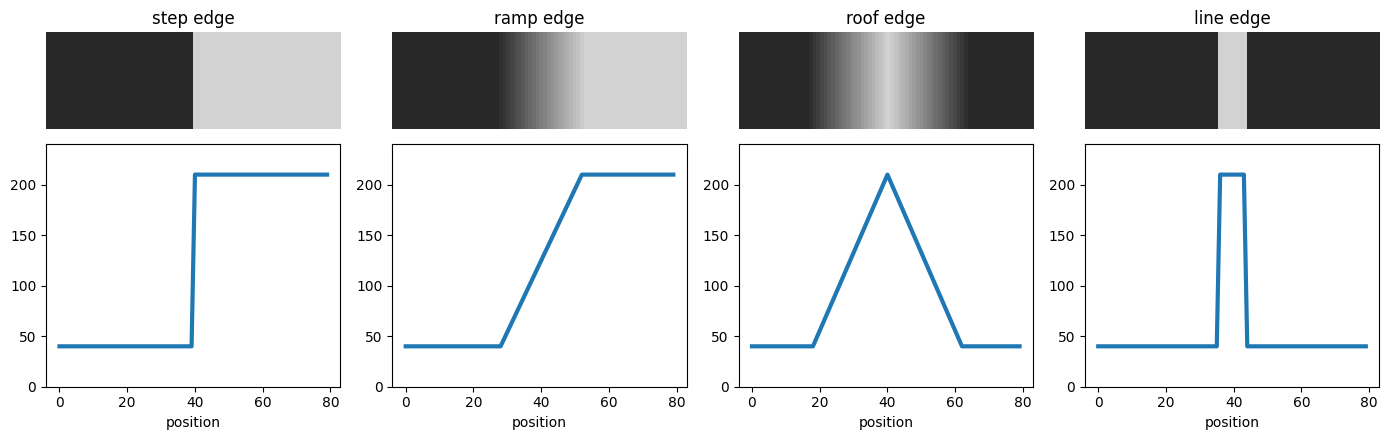

In [15]:
fig, axs = plt.subplots(2, 4, figsize=(14, 4.5), gridspec_kw={'height_ratios': [1, 2.5]})
for k, (name, prof) in enumerate(types.items()):
    axs[0, k].imshow(np.tile(prof, (10, 1)), cmap='gray', vmin=0, vmax=255, aspect='auto')
    axs[0, k].set_title(name + ' edge'); axs[0, k].axis('off')
    axs[1, k].plot(prof, lw=3); axs[1, k].set_ylim(0, 240); axs[1, k].set_xlabel('position')
plt.tight_layout(); plt.savefig('figures/s07_edge_types.png', dpi=200); plt.show()

In [16]:
row = 141
prof = coins[row].astype(float)
change = np.abs(np.convolve(prof, [1, 0, -1], mode='same')); change[:2] = 0; change[-2:] = 0
peaks = [i for i in range(2, len(change) - 2) if change[i] == change[i-2:i+3].max() and change[i] > 70]
print('edges found at columns:', peaks)

edges found at columns: [30, 31, 56, 90, 111, 141, 166, 196, 205, 213, 263, 266, 275, 278, 279, 283, 323, 327, 346]


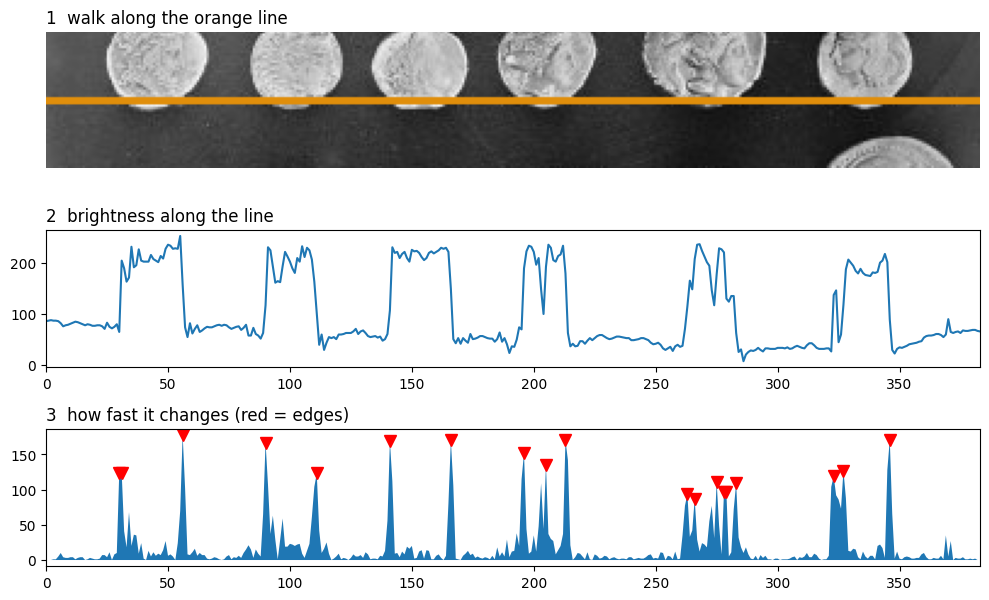

In [17]:
band = cv2.cvtColor(coins[row-28:row+28], cv2.COLOR_GRAY2RGB).copy()
cv2.line(band, (0, 28), (band.shape[1] - 1, 28), (224, 142, 11), 2)

fig, axs = plt.subplots(3, 1, figsize=(10, 6))
axs[0].imshow(band); axs[0].axis('off'); axs[0].set_title('1  walk along the orange line', loc='left')
axs[1].plot(prof); axs[1].set_title('2  brightness along the line', loc='left'); axs[1].set_xlim(0, len(prof) - 1)
axs[2].fill_between(range(len(change)), change); axs[2].plot(peaks, change[peaks], 'v', color='red', ms=9)
axs[2].set_title('3  how fast it changes (red = edges)', loc='left'); axs[2].set_xlim(0, len(prof) - 1)
plt.tight_layout(); plt.savefig('figures/s08_edge_jump.png', dpi=200); plt.show()

In [18]:
xs = np.arange(100)
f = np.where((xs > 30) & (xs < 70), 180.0, 50.0)
f = cv2.GaussianBlur(f.reshape(1, -1), (0, 0), 3).ravel()     # a smooth signal with 2 edges
df = np.gradient(f)

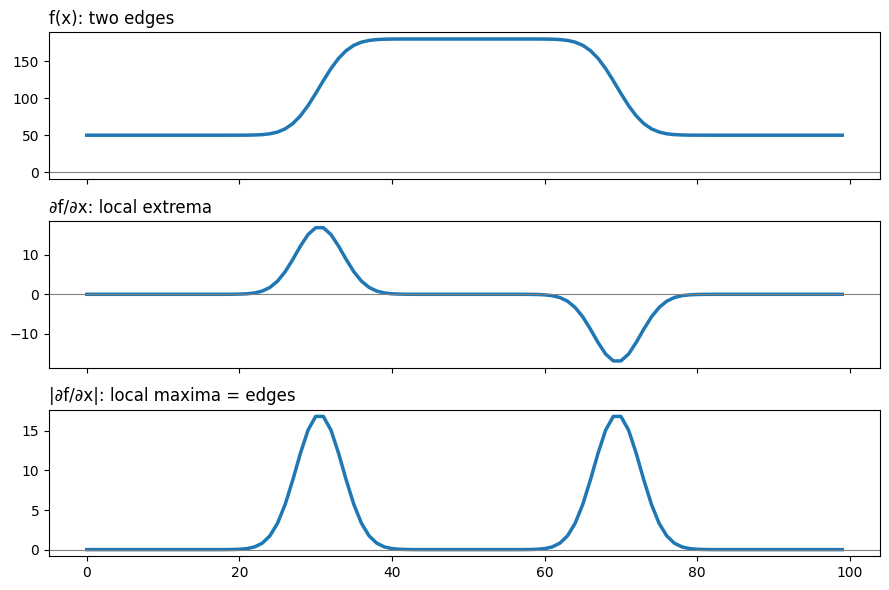

In [19]:
fig, axs = plt.subplots(3, 1, figsize=(9, 6), sharex=True)
for ax, y, t in zip(axs, [f, df, np.abs(df)], ['f(x): two edges', '∂f/∂x: local extrema', '|∂f/∂x|: local maxima = edges']):
    ax.plot(y, lw=2.5); ax.set_title(t, loc='left'); ax.axhline(0, color='gray', lw=0.8)
plt.tight_layout(); plt.savefig('figures/s10_first_derivative.png', dpi=200); plt.show()

In [20]:
f_row = np.array([10, 10, 10, 80, 80, 80, 10, 10])
d = f_row[1:] - f_row[:-1]
print('f(x)     :', f_row)
print('∂f/∂x    :', d)
print('|∂f/∂x|  :', np.abs(d))

f(x)     : [10 10 10 80 80 80 10 10]
∂f/∂x    : [  0   0  70   0   0 -70   0]
|∂f/∂x|  : [ 0  0 70  0  0 70  0]


In [21]:
T = 30
for i, v in enumerate(d):
    if abs(v) > T:
        kind = 'dark → bright' if v > 0 else 'bright → dark'
        print(f'edge between x = {i} and x = {i+1}:  {v:+d}  ({kind})')

edge between x = 2 and x = 3:  +70  (dark → bright)
edge between x = 5 and x = 6:  -70  (bright → dark)


In [22]:
def patch(kind, n=240):
    yy, xx = np.mgrid[0:n, 0:n]
    if kind == 'v':   p = np.where(xx < n // 2, 50, 200)        # changes left → right
    elif kind == 'h': p = np.where(yy < n // 2, 50, 200)        # changes top → bottom
    else:             p = np.where(xx + yy < n, 50, 200)        # changes both ways
    return cv2.GaussianBlur(p.astype(np.uint8), (0, 0), 3)

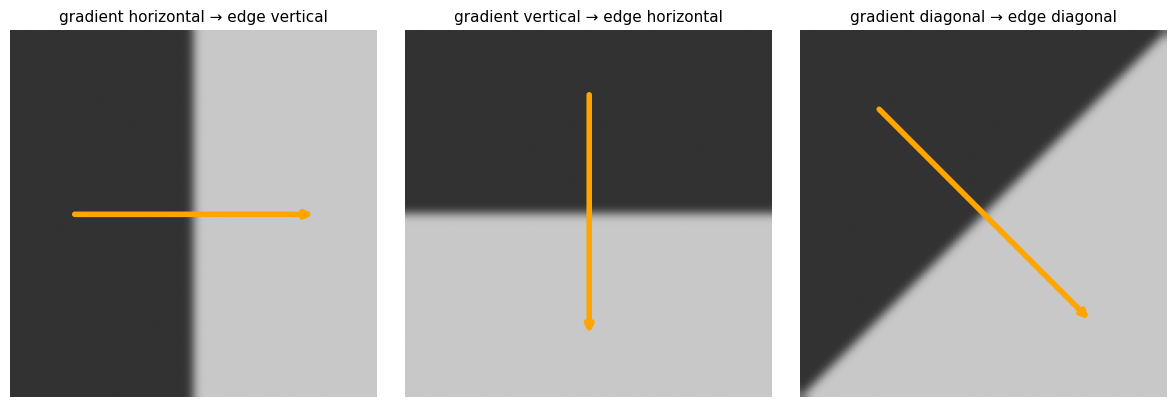

In [23]:
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
arrows = {'v': (40, 120, 160, 0), 'h': (120, 40, 0, 160), 'd': (50, 50, 140, 140)}
titles = {'v': 'gradient horizontal → edge vertical', 'h': 'gradient vertical → edge horizontal', 'd': 'gradient diagonal → edge diagonal'}
for ax, k in zip(axs, 'vhd'):
    ax.imshow(patch(k), cmap='gray', vmin=0, vmax=255); ax.axis('off'); ax.set_title(titles[k], fontsize=11)
    x0, y0, dx, dy = arrows[k]
    ax.annotate('', xy=(x0 + dx, y0 + dy), xytext=(x0, y0), arrowprops=dict(arrowstyle='-|>', color='orange', lw=4))
plt.tight_layout(); plt.savefig('figures/s12_gradient_cases.png', dpi=200); plt.show()

In [24]:
S0 = np.full((160, 160), 40.0)
S0[45:115, 45:115] = 210
S0 = cv2.GaussianBlur(S0, (0, 0), 1.6)

gx = cv2.Sobel(S0, cv2.CV_64F, 1, 0, ksize=3)     # left → right change
gy = cv2.Sobel(S0, cv2.CV_64F, 0, 1, ksize=3)     # top → bottom change
S  = np.hypot(gx, gy)                             # strength

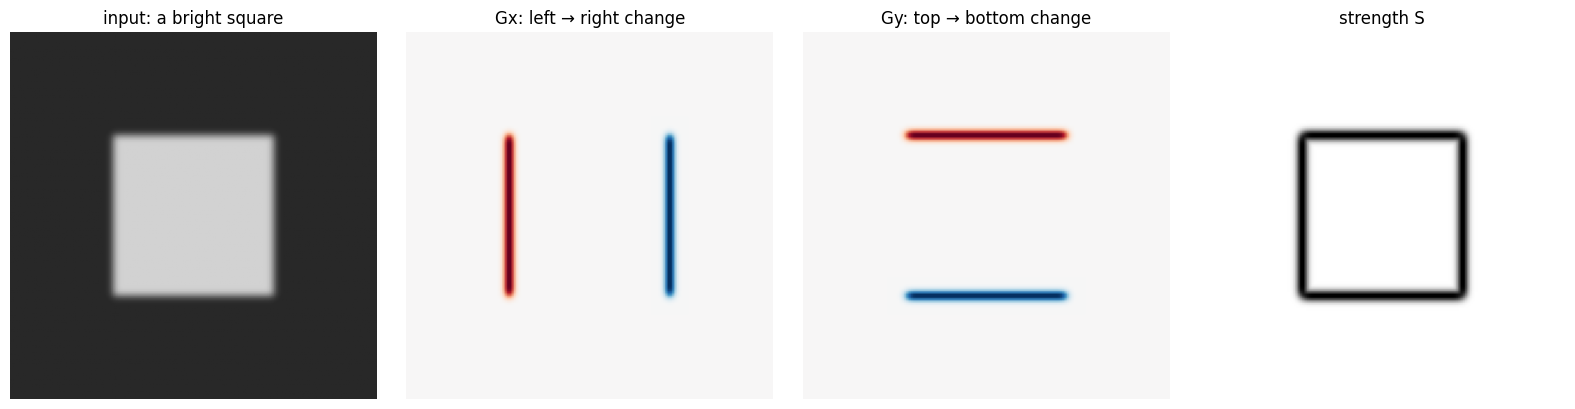

In [25]:
v = np.abs(gx).max()
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(S0, cmap='gray', vmin=0, vmax=255); axs[0].set_title('input: a bright square')
axs[1].imshow(gx, cmap='RdBu_r', vmin=-v, vmax=v); axs[1].set_title('Gx: left → right change')
axs[2].imshow(gy, cmap='RdBu_r', vmin=-v, vmax=v); axs[2].set_title('Gy: top → bottom change')
axs[3].imshow(255 - S / S.max() * 255, cmap='gray', vmin=0, vmax=255); axs[3].set_title('strength S')
for a in axs: a.axis('off')
plt.tight_layout(); plt.savefig('figures/s14_square_gx_gy.png', dpi=200); plt.show()

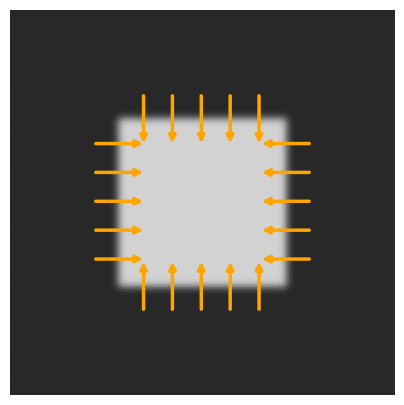

In [26]:
fig, ax = plt.subplots(figsize=(5, 5))
ax.imshow(S0, cmap='gray', vmin=0, vmax=255); ax.axis('off')
pts = [(y, 45, 1, 0) for y in range(55, 110, 12)] + [(y, 114, -1, 0) for y in range(55, 110, 12)] + \
      [(45, x, 0, 1) for x in range(55, 110, 12)] + [(114, x, 0, -1) for x in range(55, 110, 12)]
for (y, x, dx, dy) in pts:
    ax.annotate('', xy=(x + dx * 11, y + dy * 11), xytext=(x - dx * 11, y - dy * 11),
                arrowprops=dict(arrowstyle='-|>', color='orange', lw=2.5))
plt.savefig('figures/s13_square_arrows.png', dpi=200, bbox_inches='tight'); plt.show()

In [27]:
y0, x0 = 80, 45
print(f'Gx = {gx[y0, x0]:.1f},  Gy = {gy[y0, x0]:.1f}')
print(f'S  = {S[y0, x0]:.1f},  θ = {np.degrees(np.arctan2(gy[y0, x0], gx[y0, x0])):.1f}°  (0° = pointing right, into the square)')

Gx = 309.0,  Gy = 0.0
S  = 309.0,  θ = 0.0°  (0° = pointing right, into the square)


In [28]:
roberts_x = np.array([[0, 1], [-1, 0]])
roberts_y = np.array([[1, 0], [0, -1]])

prewitt_x = np.array([[-1, 0, 1], [-1, 0, 1], [-1, 0, 1]])
prewitt_y = prewitt_x.T

sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]])
sobel_y = sobel_x.T

In [29]:
kx, ky = cv2.getDerivKernels(1, 0, 5)        # derivative along x, smoothing along y
sobel5_x = (ky @ kx.T).astype(int)
print(sobel5_x)
print('Gy (5 x 5) is the transpose:'); print(sobel5_x.T)

[[ -1  -2   0   2   1]
 [ -4  -8   0   8   4]
 [ -6 -12   0  12   6]
 [ -4  -8   0   8   4]
 [ -1  -2   0   2   1]]
Gy (5 x 5) is the transpose:
[[ -1  -4  -6  -4  -1]
 [ -2  -8 -12  -8  -2]
 [  0   0   0   0   0]
 [  2   8  12   8   2]
 [  1   4   6   4   1]]


Every kernel sums to zero, so a flat area always gives 0:

In [30]:
for name, k in [('Roberts', roberts_x), ('Prewitt', prewitt_x), ('Sobel 3x3', sobel_x), ('Sobel 5x5', sobel5_x)]:
    print(f'{name:10s} sum = {k.sum()}')

Roberts    sum = 0
Prewitt    sum = 0
Sobel 3x3  sum = 0
Sobel 5x5  sum = 0


In [31]:
W2 = np.array([[10, 100],
               [10, 100]])          # a vertical edge
gx_r = np.sum(W2 * roberts_x)
gy_r = np.sum(W2 * roberts_y)
print(f'Gx = {gx_r},  Gy = {gy_r},  S = {np.hypot(gx_r, gy_r):.1f}')

Gx = 90,  Gy = -90,  S = 127.3


In [32]:
diff = np.array([[-1, 0, 1]])                       # right − left
print('Prewitt:\n', np.array([[1], [1], [1]]) @ diff)
print('Sobel:\n',   np.array([[1], [2], [1]]) @ diff)

Prewitt:
 [[-1  0  1]
 [-1  0  1]
 [-1  0  1]]
Sobel:
 [[-1  0  1]
 [-2  0  2]
 [-1  0  1]]


In [33]:
W = np.array([[10,  10,  10],
              [10,  10, 100],
              [10, 100, 100]])

In [34]:
def by_hand(W, kx, ky, name):
    px, py = W * kx, W * ky                          # products, cell by cell
    Gx, Gy = px.sum(), py.sum()
    S = np.hypot(Gx, Gy); theta = np.degrees(np.arctan2(Gy, Gx))
    print(f'--- {name} ---')
    print('Gx products:\n', px, '\n  sum =', Gx)
    print('Gy products:\n', py, '\n  sum =', Gy)
    print(f'S = {S:.1f},  θ = {theta:.0f}°\n')
    return Gx, Gy, S, theta

In [35]:
res_prewitt = by_hand(W, prewitt_x, prewitt_y, 'Prewitt')

--- Prewitt ---
Gx products:
 [[-10   0  10]
 [-10   0 100]
 [-10   0 100]] 
  sum = 180
Gy products:
 [[-10 -10 -10]
 [  0   0   0]
 [ 10 100 100]] 
  sum = 180
S = 254.6,  θ = 45°



In [36]:
res_sobel = by_hand(W, sobel_x, sobel_y, 'Sobel')

--- Sobel ---
Gx products:
 [[-10   0  10]
 [-20   0 200]
 [-10   0 100]] 
  sum = 270
Gy products:
 [[-10 -20 -10]
 [  0   0   0]
 [ 10 200 100]] 
  sum = 270
S = 381.8,  θ = 45°



The comparison table on slide 20:

In [37]:
print(f"{'':4s}{'Prewitt':>10s}{'Sobel':>10s}")
for lab, a, b in zip(['Gx', 'Gy', 'S', 'θ'], res_prewitt, res_sobel):
    print(f'{lab:4s}{a:10.1f}{b:10.1f}')

       Prewitt     Sobel
Gx       180.0     270.0
Gy       180.0     270.0
S        254.6     381.8
θ         45.0      45.0


In [38]:
b = cv2.GaussianBlur(bgray, (3, 3), 0).astype(float)
bgx = cv2.Sobel(b, cv2.CV_64F, 1, 0, ksize=3)
bgy = cv2.Sobel(b, cv2.CV_64F, 0, 1, ksize=3)
bS  = np.hypot(bgx, bgy)

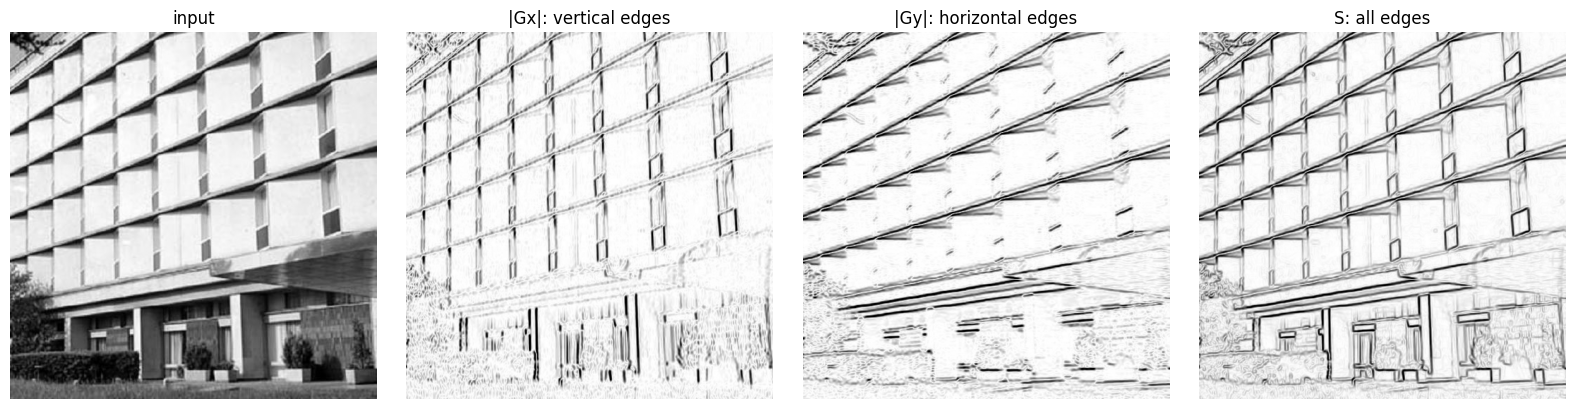

In [39]:
show([bgray[sq], edge_view(bgx)[sq], edge_view(bgy)[sq], edge_view(bS)[sq]],
     ['input', '|Gx|: vertical edges', '|Gy|: horizontal edges', 'S: all edges'], size=4, save='s21_building.png')

In [40]:
noisy = np.clip(crop + np.random.default_rng(4).normal(0, 18, crop.shape), 0, 255)

def strength(img, kx):
    gx_ = cv2.filter2D(img, cv2.CV_64F, kx.astype(float))
    gy_ = cv2.filter2D(img, cv2.CV_64F, kx.T.astype(float))
    return np.hypot(gx_, gy_)

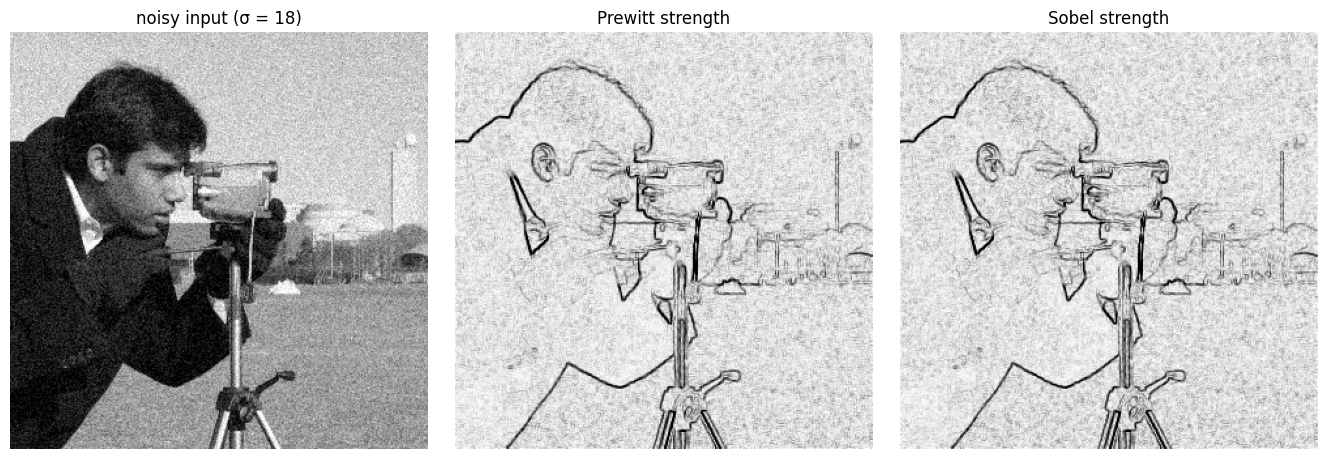

In [41]:
show([noisy.astype(np.uint8), edge_view(strength(noisy, prewitt_x)), edge_view(strength(noisy, sobel_x))],
     ['noisy input (σ = 18)', 'Prewitt strength', 'Sobel strength'], size=4.5, save='s22_prewitt_vs_sobel.png')

In [42]:
g = cv2.GaussianBlur(crop, (5, 5), 1.4).astype(float)

In [43]:
Gx = cv2.Sobel(g, cv2.CV_64F, 1, 0)
Gy = cv2.Sobel(g, cv2.CV_64F, 0, 1)
M = np.abs(Gx) + np.abs(Gy)                              # OpenCV's default (L1) strength
angle = (np.degrees(np.arctan2(Gy, Gx)) + 180) % 180     # 0 … 180 degrees

In [44]:
across = [20, 60, 90, 70, 30]          # strength across a thick edge
keep = [v if v == max(across) else 0 for v in across]
print(across, '→', keep)

[20, 60, 90, 70, 30] → [0, 0, 90, 0, 0]


In [45]:
nms = np.zeros_like(M)
H, Wd = M.shape
for i in range(1, H - 1):
    for j in range(1, Wd - 1):
        a = angle[i, j]
        if a < 22.5 or a >= 157.5:  n1, n2 = M[i, j - 1], M[i, j + 1]          # 0°: left / right
        elif a < 67.5:              n1, n2 = M[i - 1, j - 1], M[i + 1, j + 1]  # 45°
        elif a < 112.5:             n1, n2 = M[i - 1, j], M[i + 1, j]          # 90°: up / down
        else:                       n1, n2 = M[i - 1, j + 1], M[i + 1, j - 1]  # 135°
        if M[i, j] >= n1 and M[i, j] >= n2:
            nms[i, j] = M[i, j]

In [46]:
low, high = 50, 140
strong = nms >= high
weak = (nms >= low) & ~strong

In [47]:
from scipy import ndimage
labels, n = ndimage.label(strong | weak, structure=np.ones((3, 3)))      # 8-connected groups
keep_labels = np.unique(labels[strong])
my_canny = np.isin(labels, keep_labels[keep_labels > 0])
print('strong:', strong.sum(), ' weak:', weak.sum(), ' final edge pixels:', my_canny.sum())

strong: 3276  weak: 3357  final edge pixels: 4479


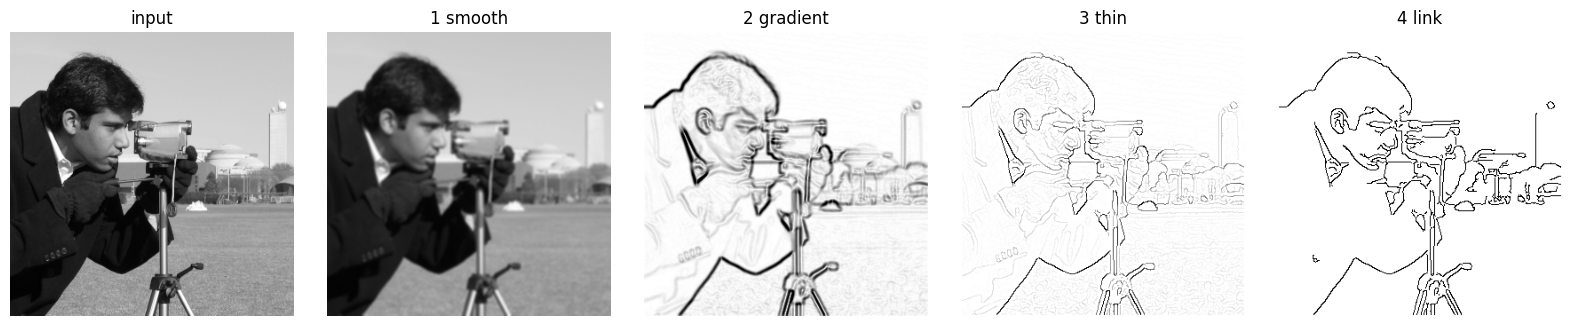

In [48]:
sc = np.percentile(M, 99.5)
view = lambda a: 255 - np.clip(a / sc * 255, 0, 255).astype(np.uint8)
show([crop, g.astype(np.uint8), view(M), view(nms), (255 - my_canny * 255).astype(np.uint8)],
     ['input', '1 smooth', '2 gradient', '3 thin', '4 link'], size=3.2, save='s23_canny_steps.png')

pixels that agree with cv2.Canny: 99.8%


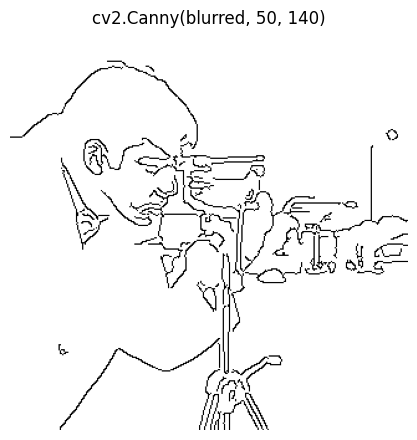

In [49]:
opencv_canny = cv2.Canny(cv2.GaussianBlur(crop, (5, 5), 1.4), 50, 140)
agree = ((opencv_canny > 0) == my_canny).mean() * 100
print(f'pixels that agree with cv2.Canny: {agree:.1f}%')
show([255 - opencv_canny], ['cv2.Canny(blurred, 50, 140)'], size=4.5)

In [50]:
cS = np.hypot(cv2.Sobel(crop.astype(float), cv2.CV_64F, 1, 0), cv2.Sobel(crop.astype(float), cv2.CV_64F, 0, 1))
th = {T: np.where(cS > T, 0, 255).astype(np.uint8) for T in (80, 200, 400)}
zoom = cv2.resize(th[200][60:160, 70:170], (320, 320), interpolation=cv2.INTER_NEAREST)

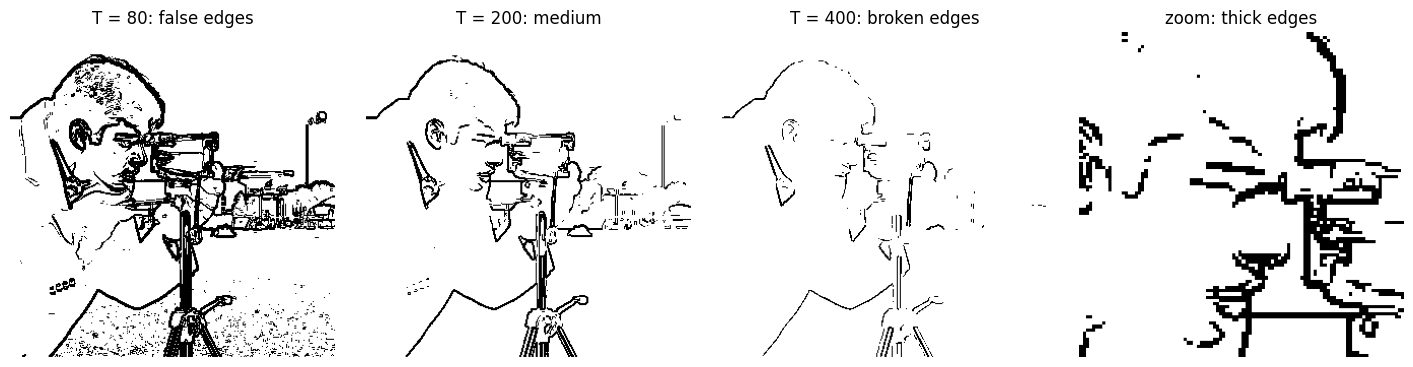

In [51]:
show([th[80], th[200], th[400], zoom], ['T = 80: false edges', 'T = 200: medium', 'T = 400: broken edges', 'zoom: thick edges'],
     size=3.6, save='s24_thresholding.png')

In [52]:
rng = np.random.default_rng(7)
eta = rng.normal(0, 25, crop.shape)                     # the noise
g_noisy = np.clip(crop + eta, 0, 255).astype(np.uint8)  # what the camera gives

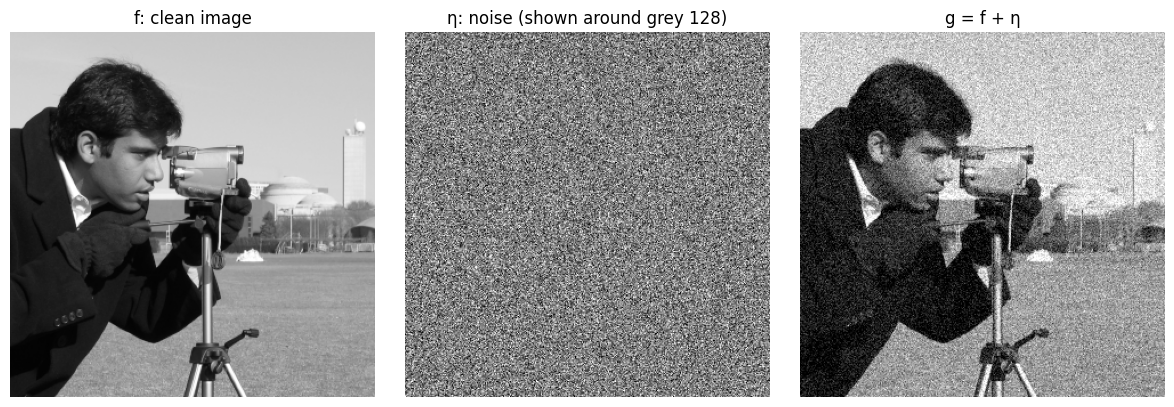

In [53]:
show([crop, np.clip(128 + 2 * eta, 0, 255).astype(np.uint8), g_noisy],
     ['f: clean image', 'η: noise (shown around grey 128)', 'g = f + η'], size=4, save='s26_noise_equation.png')

In [54]:
def gaussian_noise(img, sigma):
    return np.clip(img + rng.normal(0, sigma, img.shape), 0, 255).astype(np.uint8)

def uniform_noise(img, a, b):
    return np.clip(img + rng.uniform(a, b, img.shape), 0, 255).astype(np.uint8)

def salt_pepper(img, p):
    out = img.copy(); m = rng.random(img.shape)
    out[m < p / 2] = 0; out[m > 1 - p / 2] = 255
    return out

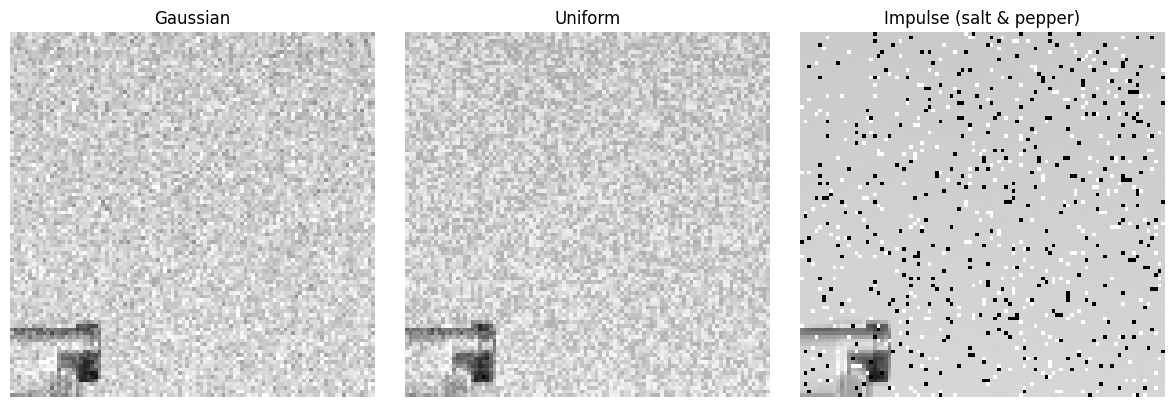

In [55]:
n_g = gaussian_noise(crop, 20)
n_u = uniform_noise(crop, -35, 35)
n_i = salt_pepper(crop, 0.08)
z = (slice(20, 120), slice(180, 280))                   # zoom on the sky
show([n_g[z], n_u[z], n_i[z]], ['Gaussian', 'Uniform', 'Impulse (salt & pepper)'], size=4, save='s27_three_noises.png')

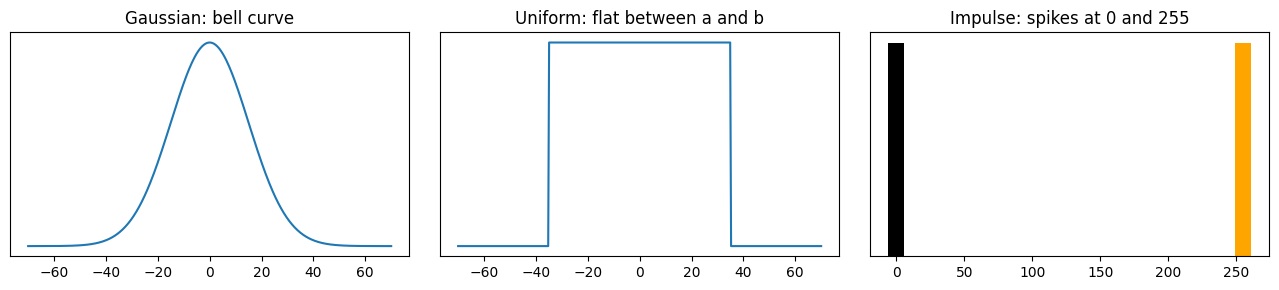

In [56]:
zz = np.linspace(-70, 70, 400)
fig, axs = plt.subplots(1, 3, figsize=(13, 3))
axs[0].plot(zz, np.exp(-zz**2 / (2 * 15**2))); axs[0].set_title('Gaussian: bell curve')
axs[1].plot(zz, np.where(np.abs(zz) <= 35, 1, 0)); axs[1].set_title('Uniform: flat between a and b')
axs[2].bar([0, 255], [0.05, 0.05], width=12, color=['black', 'orange']); axs[2].set_title('Impulse: spikes at 0 and 255')
for a in axs: a.set_yticks([])
plt.tight_layout(); plt.savefig('figures/s27_pdfs.png', dpi=200); plt.show()

In [57]:
tiny = np.array([[0, 0, 1, 1],
                 [0, 2, 2, 1],
                 [3, 2, 2, 1],
                 [3, 3, 2, 2]])
values, counts = np.unique(tiny, return_counts=True)
print('value:', values); print('count:', counts, '  total =', counts.sum())

value: [0 1 2 3]
count: [3 4 6 3]   total = 16


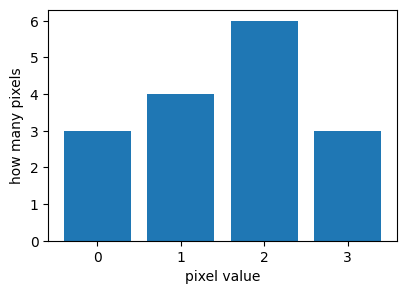

In [58]:
plt.figure(figsize=(4.5, 3)); plt.bar(values, counts)
plt.xticks(values); plt.xlabel('pixel value'); plt.ylabel('how many pixels')
plt.savefig('figures/s28_histogram.png', dpi=200, bbox_inches='tight'); plt.show()

In [59]:
tp = np.full((256, 256), 40, np.uint8)
cv2.circle(tp, (90, 150), 60, 130, -1)
cv2.rectangle(tp, (140, 40), (225, 215), 210, -1)

tests = {'clean': tp, '+ Gaussian': gaussian_noise(tp, 15), '+ uniform': uniform_noise(tp, -35, 35), '+ impulse': salt_pepper(tp, 0.10)}

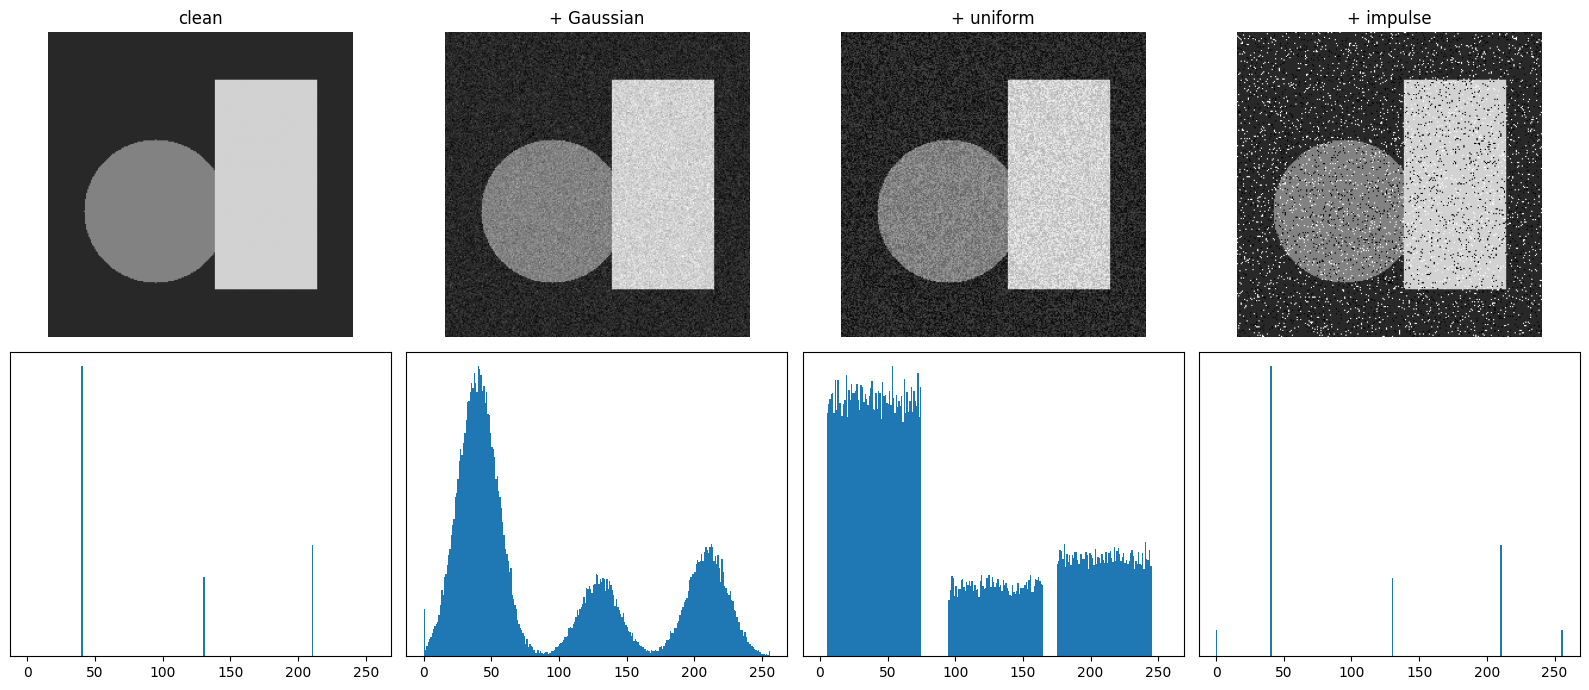

In [60]:
fig, axs = plt.subplots(2, 4, figsize=(16, 7))
for k, (name, im) in enumerate(tests.items()):
    axs[0, k].imshow(im, cmap='gray', vmin=0, vmax=255); axs[0, k].set_title(name); axs[0, k].axis('off')
    axs[1, k].hist(im.ravel(), bins=256, range=(0, 256)); axs[1, k].set_yticks([])
plt.tight_layout(); plt.savefig('figures/s29_histograms.png', dpi=200); plt.show()

In [61]:
sigma = 20
noise = rng.normal(0, sigma, 1_000_000)
print(f'within ±1σ: {(np.abs(noise) <= sigma).mean() * 100:.1f}%')
print(f'within ±2σ: {(np.abs(noise) <= 2 * sigma).mean() * 100:.1f}%')

within ±1σ: 68.3%
within ±2σ: 95.4%


In [62]:
a, b = -35, 35
print('theory     : mean =', (a + b) / 2, ' variance =', round((b - a)**2 / 12, 1), ' σ =', round(np.sqrt((b - a)**2 / 12), 1))
u = rng.uniform(a, b, 1_000_000)
print(f'simulation : mean = {u.mean():.2f}  variance = {u.var():.1f}  σ = {u.std():.1f}')

theory     : mean = 0.0  variance = 408.3  σ = 20.2
simulation : mean = -0.00  variance = 409.0  σ = 20.2


In [63]:
img512 = np.full((512, 512), 128, np.uint8)
sp = salt_pepper(img512, 0.10)            # P_pepper = P_salt = 5%
print('total pixels :', sp.size)
print('pepper (0)   :', (sp == 0).sum(), '  expected ≈', int(0.05 * sp.size))
print('salt (255)   :', (sp == 255).sum())
print('untouched    :', (sp == 128).sum())

total pixels : 262144
pepper (0)   : 13061   expected ≈ 13107
salt (255)   : 13115
untouched    : 235968


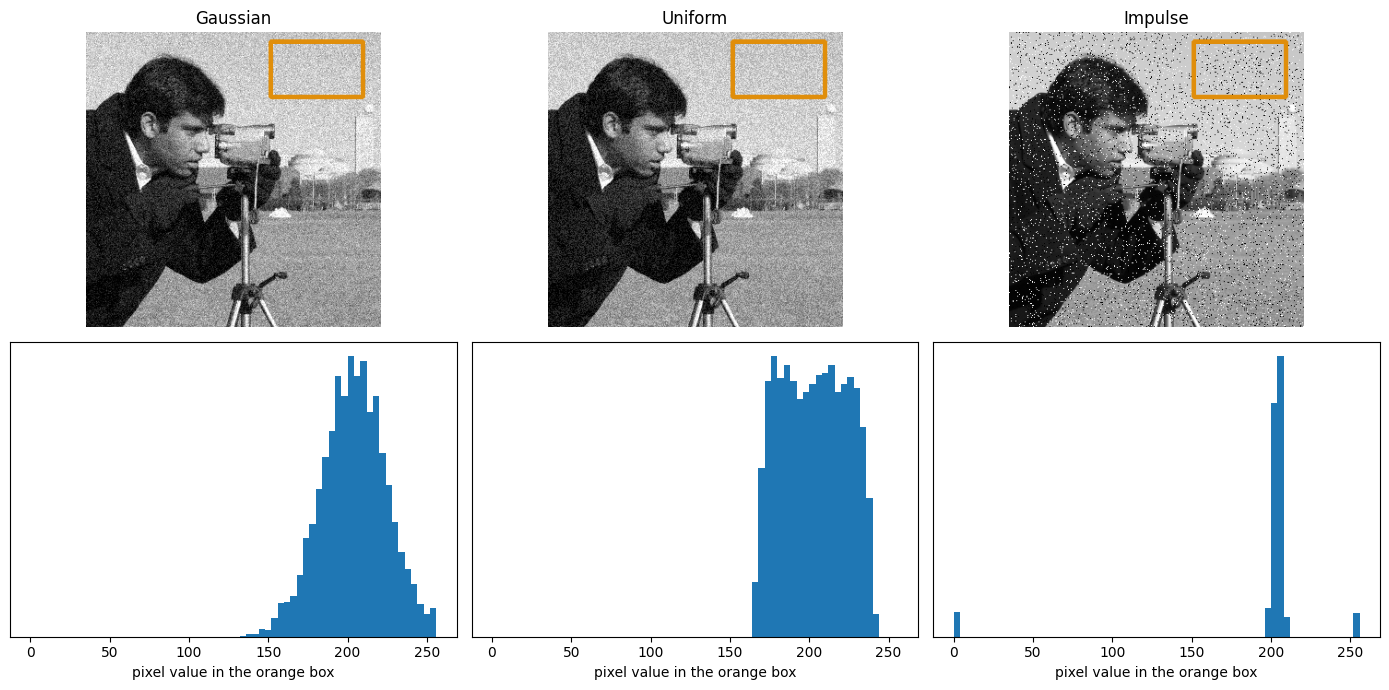

In [64]:
patch_box = (slice(10, 70), slice(200, 300))
fig, axs = plt.subplots(2, 3, figsize=(14, 7))
for k, (name, im) in enumerate([('Gaussian', n_g), ('Uniform', n_u), ('Impulse', n_i)]):
    rgb = cv2.cvtColor(im, cv2.COLOR_GRAY2RGB); cv2.rectangle(rgb, (200, 10), (300, 70), (224, 142, 11), 3)
    axs[0, k].imshow(rgb); axs[0, k].set_title(name); axs[0, k].axis('off')
    axs[1, k].hist(im[patch_box].ravel(), bins=64, range=(0, 256)); axs[1, k].set_yticks([])
    axs[1, k].set_xlabel('pixel value in the orange box')
plt.tight_layout(); plt.savefig('figures/s33_diagnose.png', dpi=200); plt.show()

Gaussian noise: 22.5 dB → Gaussian filter 28.2 dB
Impulse noise : 15.7 dB → median filter   30.8 dB


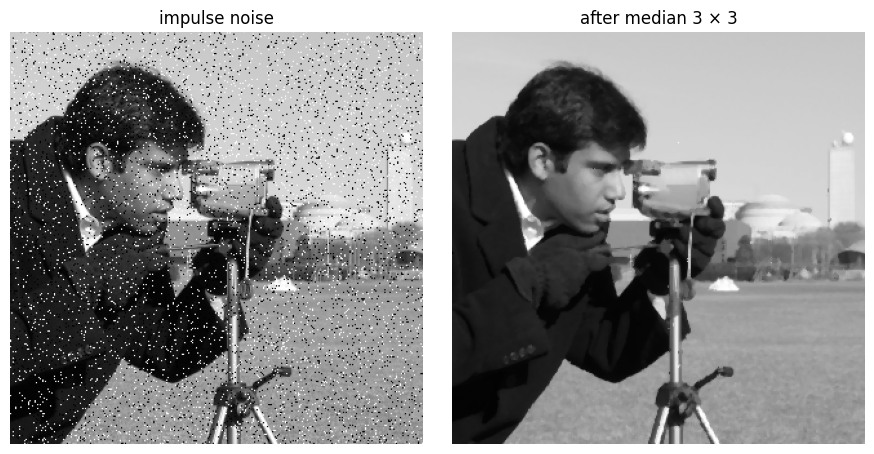

In [65]:
fixed_g = cv2.GaussianBlur(n_g, (5, 5), 1.0)
fixed_i = cv2.medianBlur(n_i, 3)
print(f'Gaussian noise: {cv2.PSNR(crop, n_g):.1f} dB → Gaussian filter {cv2.PSNR(crop, fixed_g):.1f} dB')
print(f'Impulse noise : {cv2.PSNR(crop, n_i):.1f} dB → median filter   {cv2.PSNR(crop, fixed_i):.1f} dB')
show([n_i, fixed_i], ['impulse noise', 'after median 3 × 3'], size=4.5)